In [41]:
import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import f1_score

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [40]:
TRAIN_DIR = "../data/raw/Lung_Disease_Dataset/train"
VAL_DIR = "../data/raw/Lung_Disease_Dataset/val"
MODEL_PATH = "../models/Transfer_1/efficientnet_head_best.pth"

FINETUNE_DIR = "../models/Transfer_2"
os.makedirs(FINETUNE_DIR, exist_ok=True)

BATCH_SIZE = 32
NUM_CLASSES = 5

In [26]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [27]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=val_transform
)

print("Train Images:", len(train_dataset))
print("Val Images:", len(val_dataset))

print("Classes:")
print(train_dataset.classes)

Train Images: 6054
Val Images: 2016
Classes:
['Bacterial Pneumonia', 'Corona Virus Disease', 'Normal', 'Tuberculosis', 'Viral Pneumonia']


In [30]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4
)

In [31]:
model = models.efficientnet_b0(weights=None)

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(0.3),

    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.BatchNorm1d(512),

    nn.Dropout(0.3),

    nn.Linear(512, 256),
    nn.ReLU(),
    nn.BatchNorm1d(256),

    nn.Dropout(0.2),

    nn.Linear(256, NUM_CLASSES)
)

In [32]:
checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)

print("Stage 1 model loaded successfully")
print("Best Epoch:", checkpoint["epoch"])

Stage 1 model loaded successfully
Best Epoch: 14


In [33]:
for param in model.features.parameters():
    param.requires_grad = False

In [34]:
for param in model.features[7].parameters():
    param.requires_grad = True

for param in model.features[8].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

In [35]:
trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total = sum(
    p.numel()
    for p in model.parameters()
)

print(f"Trainable Params: {trainable:,}")
print(f"Total Params: {total:,}")
print(f"Percentage: {100*trainable/total:.2f}%")

Trainable Params: 1,919,413
Total Params: 4,797,569
Percentage: 40.01%


In [36]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-5
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [43]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_macro_f1": []
}

best_macro_f1 = 0.0

patience = 3
counter = 0

In [ ]:
'''
EPOCHS = 10

for epoch in range(EPOCHS):

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print("-" * 50)

    # =====================
    # TRAIN
    # =====================

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    # =====================
    # VALIDATION
    # =====================

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    val_loss = running_loss / len(val_loader)
    val_acc = 100 * correct / total

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    scheduler.step(macro_f1)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_macro_f1"].append(macro_f1)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.2f}%")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.2f}%")
    print(f"Macro F1   : {macro_f1:.4f}")

    # =====================
    # SAVE BEST MODEL
    # =====================

    if macro_f1 > best_macro_f1:

        best_macro_f1 = macro_f1
        counter = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_macro_f1": best_macro_f1
            },
            os.path.join(
                FINETUNE_DIR,
                "efficientnet_finetuned_best.pth"
            )
        )

        print("✅ Best model saved")

    else:

        counter += 1

        if counter >= patience:

            print("🛑 Early stopping triggered")
            break

        '''


Epoch [1/10]
--------------------------------------------------


100%|██████████| 190/190 [01:49<00:00,  1.74it/s]


Train Loss : 0.4082
Train Acc  : 83.42%
Val Loss   : 0.4657
Val Acc    : 84.92%
Macro F1   : 0.8468
✅ Best model saved

Epoch [2/10]
--------------------------------------------------


100%|██████████| 190/190 [01:48<00:00,  1.76it/s]


Train Loss : 0.3962
Train Acc  : 83.93%
Val Loss   : 0.3733
Val Acc    : 85.22%
Macro F1   : 0.8487
✅ Best model saved

Epoch [3/10]
--------------------------------------------------


...

Train Loss : 0.3768
Train Acc  : 84.41%
Val Loss   : 0.5385
Val Acc    : 83.83%
Macro F1   : 0.8353

Epoch [4/10]
--------------------------------------------------


100%|██████████| 190/190 [01:38<00:00,  1.92it/s]


Train Loss : 0.3891
Train Acc  : 84.90%
Val Loss   : 0.3885
Val Acc    : 83.38%
Macro F1   : 0.8317

Epoch [5/10]
--------------------------------------------------


100%|██████████| 190/190 [01:33<00:00,  2.03it/s]


Train Loss : 0.3881
Train Acc  : 84.61%
Val Loss   : 0.3755
Val Acc    : 83.83%
Macro F1   : 0.8363
🛑 Early stopping triggered


In [45]:
history_df = pd.DataFrame(history)

history_df.to_csv(
    os.path.join(
        FINETUNE_DIR,
        "efficientnet_finetune_history.csv"
    ),
    index=False
)

print("History saved")

print(f"Best Macro F1: {best_macro_f1:.4f}")

History saved
Best Macro F1: 0.8487


In [46]:
history_df = pd.DataFrame(history)

history_df.to_csv(
    os.path.join(
        FINETUNE_DIR,
        "efficientnet_finetune_history.csv"
    ),
    index=False
)

print("History saved")

print(f"Best Macro F1: {best_macro_f1:.4f}")

History saved
Best Macro F1: 0.8487


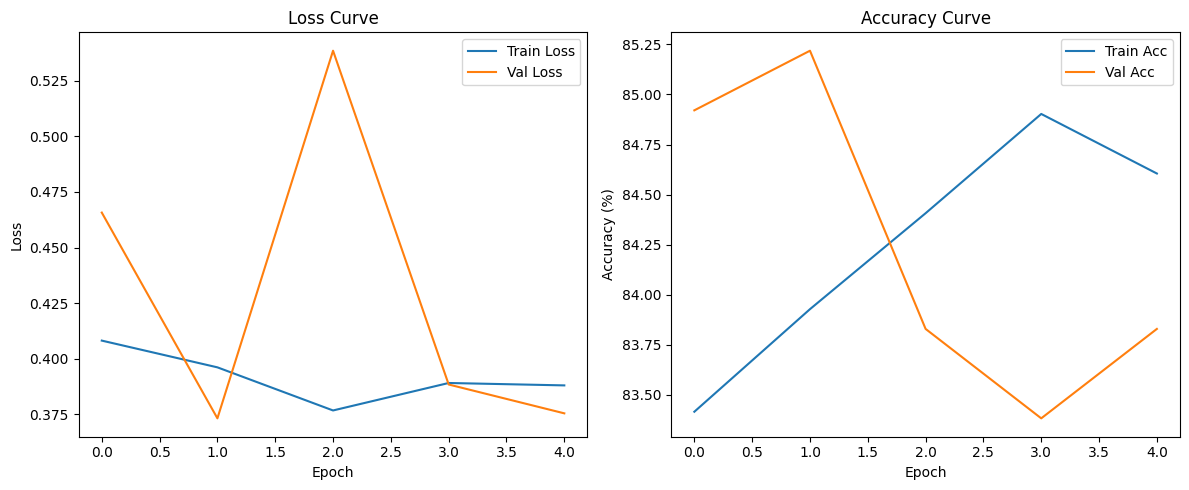

In [49]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        FINETUNE_DIR,
        "training_curves.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

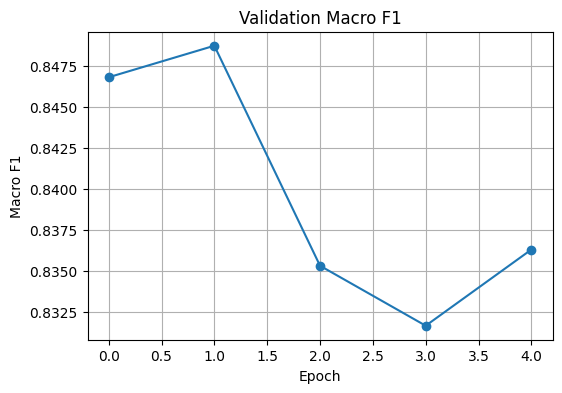

In [50]:
plt.figure(figsize=(6,4))

plt.plot(
    history["val_macro_f1"],
    marker="o"
)

plt.title("Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")

plt.grid(True)

plt.savefig(
    os.path.join(
        FINETUNE_DIR,
        "macro_f1_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

metrics = {
    "Accuracy":[accuracy_score(all_labels, all_preds)],
    "Macro Precision":[precision_score(all_labels, all_preds, average="macro")],
    "Macro Recall":[recall_score(all_labels, all_preds, average="macro")],
    "Macro F1":[f1_score(all_labels, all_preds, average="macro")]
}

metrics_df = pd.DataFrame(metrics)

metrics_df.to_csv(
    os.path.join(
        FINETUNE_DIR,
        "final_metrics.csv"
    ),
    index=False
)

metrics_df

,Accuracy,Macro Precision,Macro Recall,Macro F1
0,0.838294,0.839306,0.837628,0.836309


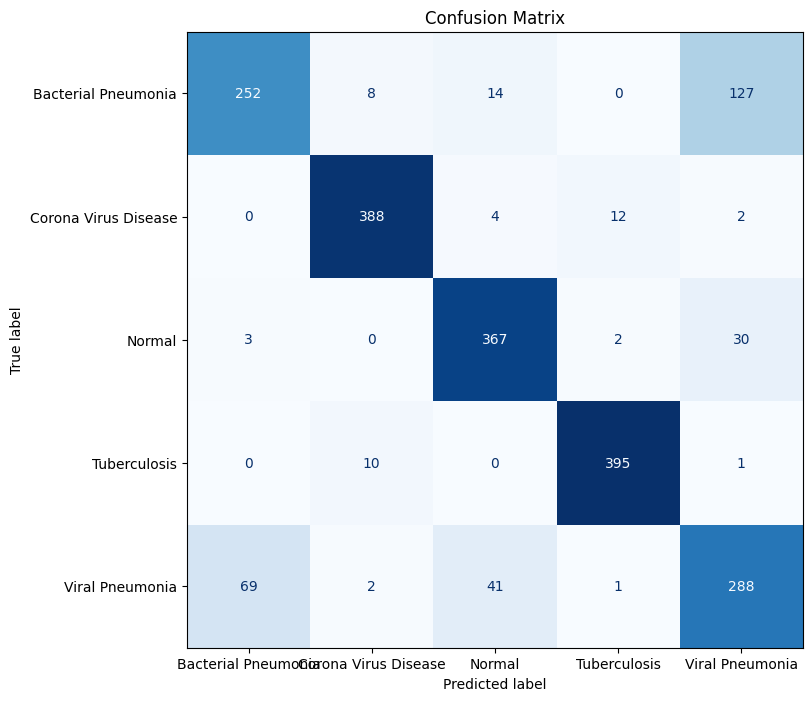

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = [
    'Bacterial Pneumonia',
    'Corona Virus Disease',
    'Normal',
    'Tuberculosis',
    'Viral Pneumonia'
]

cm = confusion_matrix(
    all_labels,
    all_preds
)

fig, ax = plt.subplots(figsize=(8,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix")

plt.savefig(
    os.path.join(
        FINETUNE_DIR,
        "confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()